# Predicting Downstream Task Performance from Representation Geometry

This notebook evaluates whether geometric properties of pretrained RoBERTa embeddings correlate with downstream NLP task performance across GLUE and SuperGLUE benchmarks.

## 1. Project Setup

We configure the notebook environment and add the project root to the Python path.

In [1]:
# Standard library
import os
import sys

# Numerical / data
import numpy as np
import pandas as pd

# Reproducibility
np.random.seed(42)

# Visualization
import matplotlib.pyplot as plt

# Statistics
from scipy import stats

# Path Setup
PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Project modules
from src.tasks import task_configs

from src.embeddings import (
    load_roberta,
    load_and_embed_task,
)

from src.metrics import (
    linear_probe_loss,
    mean_cosine_similarity,
    intrinsic_dimensionality,
    fisher_separability,
    cka,
)

## 2. Load Pretrained RoBERTa Model

We use frozen pretrained RoBERTa-base embeddings extracted from the final hidden layer CLS token representation.

In [2]:
# Load pretrained tokenizer and encoder
tokenizer, model_hf = load_roberta()

print("✅ RoBERTa-base loaded")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ RoBERTa-base loaded


## 3. Generate Task Embeddings

Each benchmark dataset is encoded into RoBERTa embedding vectors representing its geometry in representation space.

Embeddings and labels are cached locally to avoid recomputation in future runs.

In [3]:
# Directory for cached embeddings
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "data", "embeddings_roberta")

os.makedirs(OUTPUT_DIR, exist_ok=True)

for task_name, cfg in task_configs.items():

    embedding_save_path = os.path.join(OUTPUT_DIR, f"{task_name}_embeddings.npy")
    label_save_path = os.path.join(OUTPUT_DIR, f"{task_name}_labels.npy")

    # Skip tasks already processed
    if os.path.exists(embedding_save_path):
        print(f"⏭️  {task_name} already exists, skipping.")
        continue

    print(f"\n📦 Loading {task_name}...")

    try:

        embeddings, labels = load_and_embed_task(
            task_name,
            cfg,
            tokenizer,
            model_hf
        )

        # Persist embeddings + labels
        np.save(embedding_save_path, embeddings)
        np.save(label_save_path, labels)

        print(f"   ✅ Saved → shape {embeddings.shape}")

    except Exception as ex:
        print(f"   ❌ Failed on {task_name}: {ex}")
        
print("\n🎉 All tasks encoded!")

⏭️  sst2 already exists, skipping.
⏭️  mnli already exists, skipping.
⏭️  qnli already exists, skipping.
⏭️  qqp already exists, skipping.
⏭️  rte already exists, skipping.
⏭️  mrpc already exists, skipping.
⏭️  cola already exists, skipping.
⏭️  stsb already exists, skipping.
⏭️  wnli already exists, skipping.
⏭️  cb already exists, skipping.
⏭️  boolq already exists, skipping.
⏭️  wic already exists, skipping.
⏭️  multirc already exists, skipping.

🎉 All tasks encoded!


## 4. Verify Saved Embeddings

We verify that embeddings and labels were successfully generated and saved for each benchmark task.

In [4]:
all_tasks = list(task_configs.keys())

print(f"{'Task':20s} {'Shape':18s} Labels")
print("-" * 55)

for task in all_tasks:

    embedding_path = os.path.join(
        OUTPUT_DIR,
        f"{task}_embeddings.npy"
    )

    label_path = os.path.join(
        OUTPUT_DIR,
        f"{task}_labels.npy"
    )

    if os.path.exists(embedding_path):

        e = np.load(embedding_path)
        l = np.load(label_path)

        print(
            f"{task:20s} "
            f"{str(e.shape):18s} "
            f"{str(l.shape)}"
        )

    else:
        print(f"{task:20s} ❌ MISSING")

Task                 Shape              Labels
-------------------------------------------------------
sst2                 (872, 768)         (872,)
mnli                 (2000, 768)        (2000,)
qnli                 (2000, 768)        (2000,)
qqp                  (2000, 768)        (2000,)
rte                  (277, 768)         (277,)
mrpc                 (408, 768)         (408,)
cola                 (1043, 768)        (1043,)
stsb                 (1500, 768)        (1500,)
wnli                 (71, 768)          (71,)
cb                   (56, 768)          (56,)
boolq                (2000, 768)        (2000,)
wic                  (638, 768)         (638,)
multirc              (2000, 768)        (2000,)


## 5. Compute Geometry Metrics

We compute five geometric properties of each task's embedding matrix.

In [5]:
results = []

for task in all_tasks:

    embedding_path = os.path.join(OUTPUT_DIR, f"{task}_embeddings.npy")
    label_path = os.path.join(OUTPUT_DIR, f"{task}_labels.npy")

    if not os.path.exists(embedding_path):
        print(f"❌ {task} embeddings missing, skipping.")
        continue

    print(f"\nComputing metrics for {task}...")

    # Load embeddings + labels
    e = np.load(embedding_path)
    l = np.load(label_path)

    # Compute geometry metrics
    lpl = linear_probe_loss(e, l)
    cos = mean_cosine_similarity(e)
    idim = intrinsic_dimensionality(e)
    fisher = fisher_separability(e, l)
    cka_score = cka(e, l)

    results.append({
        "task": task,
        "linear_probe_loss": round(lpl, 4),
        "mean_cosine_sim": round(cos, 4),
        "intrinsic_dim": idim,
        "fisher_separability": round(fisher, 4),
        "cka": round(cka_score, 4),
    })
    
# Consolidate metrics into dataframe
df_all = pd.DataFrame(results)

# Persist metrics table
METRICS_PATH = os.path.join(PROJECT_ROOT, "outputs", "metrics.csv")
df_all.to_csv(METRICS_PATH, index=False)

print(f"\n✅ Metrics table updated — {len(df_all)} tasks total")


Computing metrics for sst2...

Computing metrics for mnli...

Computing metrics for qnli...

Computing metrics for qqp...

Computing metrics for rte...

Computing metrics for mrpc...

Computing metrics for cola...

Computing metrics for stsb...

Computing metrics for wnli...

Computing metrics for cb...

Computing metrics for boolq...

Computing metrics for wic...

Computing metrics for multirc...

✅ Metrics table updated — 13 tasks total


## 6. Add Benchmark Performance Scores

We add reference benchmark performance scores reported for RoBERTa-base on GLUE and SuperGLUE tasks.

These values are used only for downstream correlation analysis.

In [6]:
all_accuracy = {
    # GLUE Tasks from Table 8 of Liu et al. (2019)
    "sst2":    0.948,
    "mnli":    0.876,
    "qnli":    0.928,
    "qqp":     0.919,
    "rte":     0.787,
    "mrpc":    0.902,
    "cola":    0.636,
    "stsb":    0.912,
    "wnli":    0.657,
    # SuperGLUE tasks Wang et al. (2019) from official SuperGLUE leaderboard
    "cb":      0.821,
    "boolq":   0.867,
    "wic":     0.694,
    "multirc": 0.722,
}

df_all["downstream_accuracy"] = df_all["task"].map(all_accuracy)

# sanity check
missing = df_all[df_all["downstream_accuracy"].isnull()]
if len(missing) > 0:
    print(f"⚠️ Missing accuracy for: {missing['task'].tolist()}")
else:
    print("✅ All tasks have accuracy numbers")

METRICS_PATH = os.path.join(PROJECT_ROOT, "outputs", "metrics.csv")
df_all.to_csv(METRICS_PATH, index=False)

print("\n=== COMPLETE DATASET ===")
print(df_all.to_string(index=False))

✅ All tasks have accuracy numbers

=== COMPLETE DATASET ===
   task  linear_probe_loss  mean_cosine_sim  intrinsic_dim  fisher_separability    cka  downstream_accuracy
   sst2             0.1926           0.9982            158               0.0109 0.0805                0.948
   mnli             0.4900           0.9962            151               0.0024 0.0116                0.876
   qnli             0.3510           0.9955            130               0.0015 0.0080                0.928
    qqp             0.2705           0.9975            152               0.0056 0.0503                0.919
    rte             0.4438           0.9961             97               0.0046 0.0302                0.787
   mrpc             0.2916           0.9969            121               0.0064 0.0492                0.902
   cola             0.2866           0.9965            111               0.0056 0.0225                0.636
   stsb             0.7340           0.9961            121               0.0

## 7. Visualize Metric Correlations

We visualize the relationship between each geometry metric and downstream task accuracy.

  linear_probe_loss: r = -0.0614
  mean_cosine_sim: r = 0.0490
  intrinsic_dim: r = 0.5657
  fisher_separability: r = -0.0097
  cka: r = 0.0300


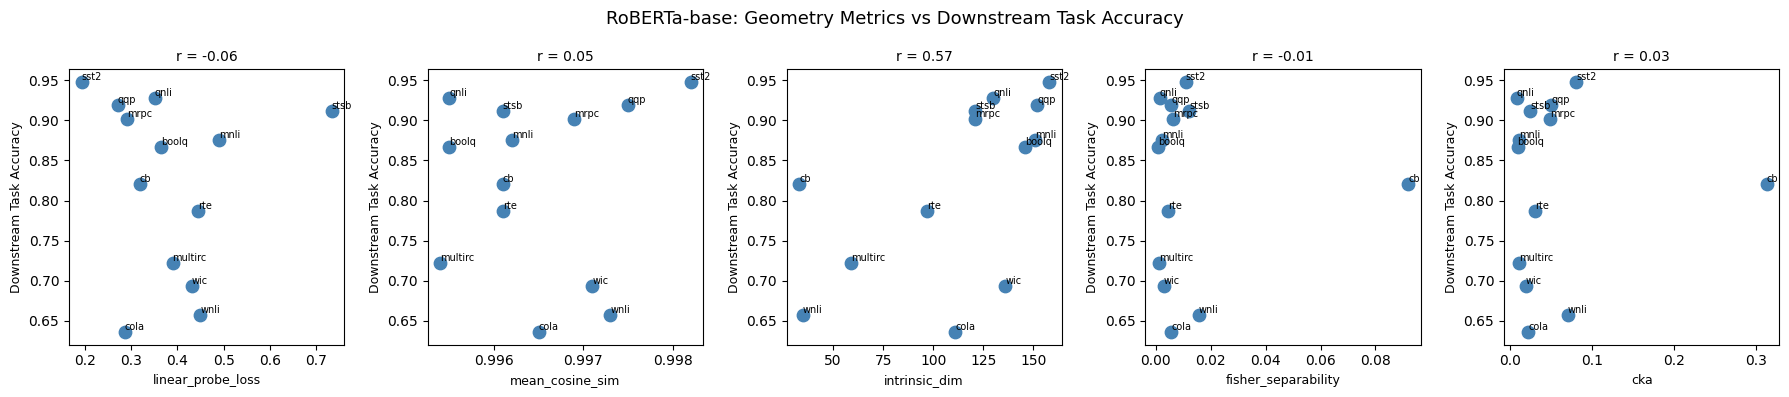

✅ Saved metric_correlations.png


In [7]:
df = df_all.copy()

metrics = [
    "linear_probe_loss",
    "mean_cosine_sim",
    "intrinsic_dim",
    "fisher_separability",
    "cka"
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("RoBERTa-base: Geometry Metrics vs Downstream Task Accuracy", fontsize=13)

for ax, metric in zip(axes, metrics):
    ax.scatter(df[metric], df["downstream_accuracy"], color="steelblue", s=80)

    for _, row in df.iterrows():
        ax.annotate(
            row["task"],
            (row[metric], row["downstream_accuracy"]),
            fontsize=7,
            ha='left',
            va='bottom'
        )

    ax.set_xlabel(metric, fontsize=9)
    ax.set_ylabel("Downstream Task Accuracy", fontsize=9)

    corr = df[metric].corr(df["downstream_accuracy"])
    print(f"  {metric}: r = {corr:.4f}")

    ax.set_title(f"r = {corr:.2f}", fontsize=10)

plt.tight_layout()

os.makedirs(os.path.join(PROJECT_ROOT, "outputs", "figures"), exist_ok=True)
OUTPUT_PATH = os.path.join(PROJECT_ROOT, "outputs", "figures", "metric_correlations.png")
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved metric_correlations.png")

## 8. Aggregate Correlation Analysis

We summarize the Pearson correlation between each geometry metric and downstream benchmark accuracy.

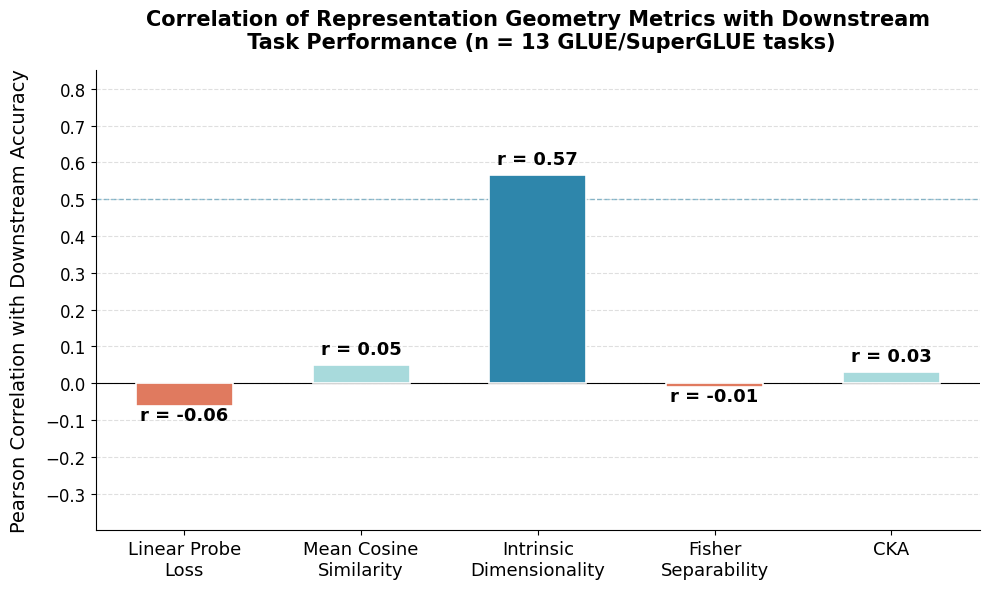

✅ Saved metric_correlations_summary.png


In [8]:
df = df_all.copy()

metrics = ["linear_probe_loss", "mean_cosine_sim",
           "intrinsic_dim", "fisher_separability", "cka"]

labels = ["Linear Probe\nLoss", "Mean Cosine\nSimilarity",
          "Intrinsic\nDimensionality", "Fisher\nSeparability", "CKA"]

r_values = [df[m].corr(df["downstream_accuracy"]) for m in metrics]

# Color bars by sign and whether it's your key finding
colors = []
for i, (m, r) in enumerate(zip(metrics, r_values)):
    if m == "intrinsic_dim":
        colors.append("#2E86AB")   # strong blue — your key finding
    elif r >= 0:
        colors.append("#A8DADC")   # light blue — weak positive
    else:
        colors.append("#E07A5F")   # muted red — weak negative

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(labels, r_values, color=colors, edgecolor="white",
              linewidth=1.2, width=0.55, zorder=3)

# Reference lines
ax.axhline(0, color="black", linewidth=0.8, zorder=2)
ax.axhline(0.5, color="#2E86AB", linewidth=1.0,
           linestyle="--", alpha=0.5, zorder=2)
ax.axhline(-0.5, color="#E07A5F", linewidth=1.0,
           linestyle="--", alpha=0.5, zorder=2)

# Annotate r values on each bar
for bar, r in zip(bars, r_values):
    ypos = r + 0.02 if r >= 0 else r - 0.05
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f"r = {r:.2f}", ha="center", va="bottom",
            fontsize=13, fontweight="bold", color="black")

# Styling
ax.set_ylim(-0.4, 0.85)
ax.set_ylabel("Pearson Correlation with Downstream Accuracy",
              fontsize=14, labelpad=12)
ax.set_title("Correlation of Representation Geometry Metrics with Downstream\n Task Performance (n = 13 GLUE/SuperGLUE tasks)",
             fontsize=15, fontweight="bold", pad=16)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=12)
ax.set_yticks([-0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

OUTPUT_PATH = os.path.join(PROJECT_ROOT, "outputs", "figures", "metric_correlations_summary.png")
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved metric_correlations_summary.png")

## 9. Intrinsic Dimensionality Analysis

Finally, we examine the relationship between intrinsic dimensionality and downstream task performance in greater detail using a regression analysis.

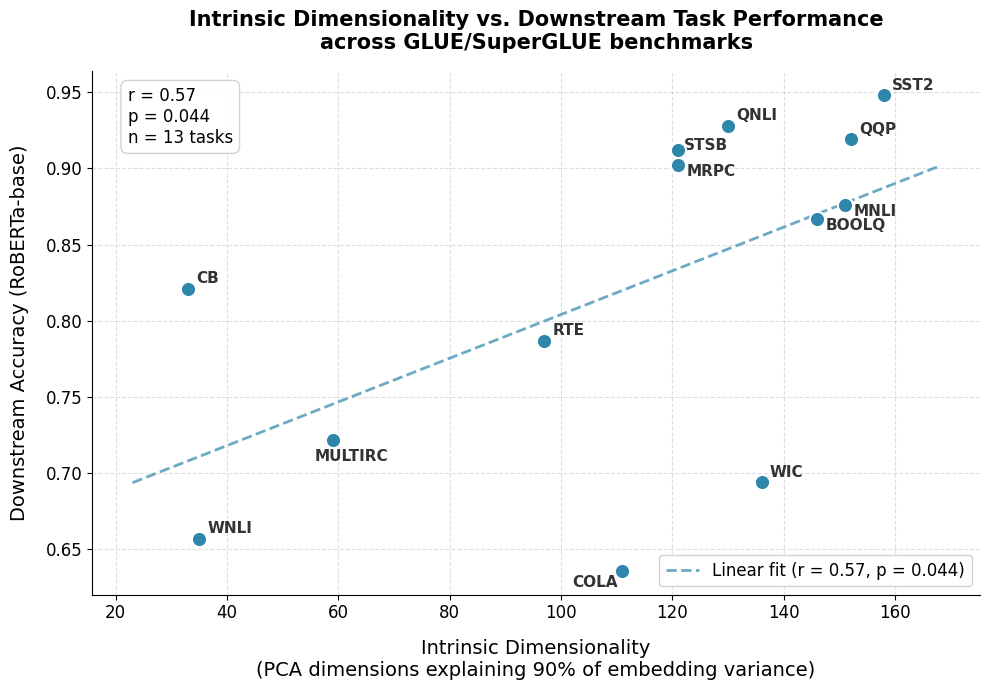

✅ Saved intrinsic_dim_regression.png


In [9]:
df = df_all.copy()

x = df["intrinsic_dim"].values
y = df["downstream_accuracy"].values
tasks = df["task"].values

# Compute trend line
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min() - 10, x.max() + 10, 200)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(10, 7))

# Trend line behind points
ax.plot(x_line, y_line, color="#2E86AB", linewidth=2,
        linestyle="--", alpha=0.7, zorder=2, label=f"Linear fit (r = {r_value:.2f}, p = {p_value:.3f})")

# Scatter points
ax.scatter(x, y, color="#2E86AB", s=120, zorder=4,
           edgecolors="white", linewidths=1.5)

# Label each task point — with smart offset to reduce overlap
# Manually tune offsets for cleaner layout
offsets = {
    "sst2":    (6, 4),
    "mnli":    (6, -8),
    "qnli":    (6, 4),
    "qqp":     (6, 4),
    "rte":     (6, 4),
    "mrpc":    (6, -8),
    "cola":    (-36, -12),
    "stsb":    (4, 0),
    "wnli":    (6, 4),
    "cb":      (6, 4),
    "boolq":   (6, -8),
    "wic":     (6, 4),
    "multirc": (-13, -15),
}

for xi, yi, task in zip(x, y, tasks):
    dx, dy = offsets.get(task, (6, 4))
    ax.annotate(task.upper(),
                xy=(xi, yi),
                xytext=(dx, dy),
                textcoords="offset points",
                fontsize=11,
                color="#333333",
                fontweight="bold",
                arrowprops=dict(arrowstyle="-", color="#aaaaaa",
                                lw=0.8) if abs(dx) > 6 or abs(dy) > 6 else None)

# Axis labels and title
ax.set_xlabel("Intrinsic Dimensionality\n(PCA dimensions explaining 90% of embedding variance)",
              fontsize=14, labelpad=12)
ax.set_ylabel("Downstream Accuracy (RoBERTa-base)",
              fontsize=14, labelpad=12)
ax.set_title("Intrinsic Dimensionality vs. Downstream Task Performance\nacross GLUE/SuperGLUE benchmarks",
             fontsize=15, fontweight="bold", pad=16)

# Legend and stats box
ax.legend(fontsize=12, loc="lower right", framealpha=0.9)

stats_text = f"r = {r_value:.2f}\np = {p_value:.3f}\nn = 13 tasks"
ax.text(0.04, 0.97, stats_text,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#cccccc", alpha=0.9))

# Styling
ax.tick_params(axis='both', labelsize=12)
ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

OUTPUT_PATH = os.path.join(PROJECT_ROOT, "outputs", "figures", "intrinsic_dim_regression.png")
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved intrinsic_dim_regression.png")